# Mobile F2P — Exploratory Data Analysis

Homescapes-type game · 10 000 synthetic players · Portfolio case study

**Contents**
1. Setup & data loading
2. Dataset overview
3. Retention analysis — D1 / D7 / D30
4. Cohort heatmap
5. A/B test — uplift, confidence intervals, power analysis
6. Behavioral segmentation
7. Session depth & engagement distribution
8. Monetization & LTV proxy
9. Churn risk signals
10. Summary & recommendations


## 1. Setup & data loading

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1120',
    'axes.facecolor':   '#0a0b14',
    'axes.edgecolor':   '#1e2235',
    'axes.labelcolor':  '#94a3b8',
    'axes.titlecolor':  '#e2e8f0',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e2235',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
    'legend.facecolor': '#0f1120',
    'legend.edgecolor': '#1e2235',
})

ACCENT = ['#6366f1', '#22d3ee', '#f472b6', '#34d399', '#fb923c']
SEG_COLORS = {'Whale': '#6366f1', 'Dolphin': '#22d3ee', 'Minnow': '#34d399', 'Ghost': '#64748b'}


In [5]:
# Run data/generate_dataset.py first if CSVs are missing
players  = pd.read_csv('../data/players.csv')
cohorts  = pd.read_csv('../data/cohort_retention.csv')
ab_daily = pd.read_csv('../data/ab_daily.csv')

print(f'Players : {len(players):,}')
print(f'Cohorts : {cohorts["cohort"].nunique()} cohorts x {cohorts["week"].nunique()} weeks')
print(f'AB daily: {len(ab_daily)} rows')


Players : 50,000
Cohorts : 6 cohorts x 4 weeks
AB daily: 62 rows


## 2. Dataset overview

In [6]:
players.head(8)


,segment,ab_group,ret_d1,ret_d7,ret_d30,sessions_w1,levels_cleared,spend_30d
0,Ghost,treatment,0.1952,0.0762,0.0304,0,0,0.00
1,Minnow,treatment,0.5149,0.2596,0.0752,2,14,0.00
2,Ghost,treatment,0.2846,0.0131,0.0131,0,0,0.00
3,Minnow,control,0.5279,0.1651,0.0568,7,0,0.00
4,Dolphin,control,0.6273,0.4365,0.1223,9,16,26.47
5,Ghost,treatment,0.2574,0.0010,0.0010,0,0,0.00
6,Ghost,treatment,0.1946,0.0493,0.0493,1,3,0.00
7,Ghost,control,0.2677,0.0588,0.0485,2,0,0.00


In [7]:
players.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
ret_d1,50000.0,0.508,0.193,0.005,0.319,0.534,0.641,1.000
ret_d7,50000.0,0.232,0.153,0.000,0.107,0.222,0.322,0.822
ret_d30,50000.0,0.087,0.082,0.000,0.024,0.070,0.126,0.448
sessions_w1,50000.0,3.165,3.017,0.000,1.000,3.000,5.000,18.000
levels_cleared,50000.0,11.436,11.908,0.000,1.000,8.000,17.000,71.000
spend_30d,50000.0,14.773,41.995,0.000,0.000,0.000,6.150,379.860


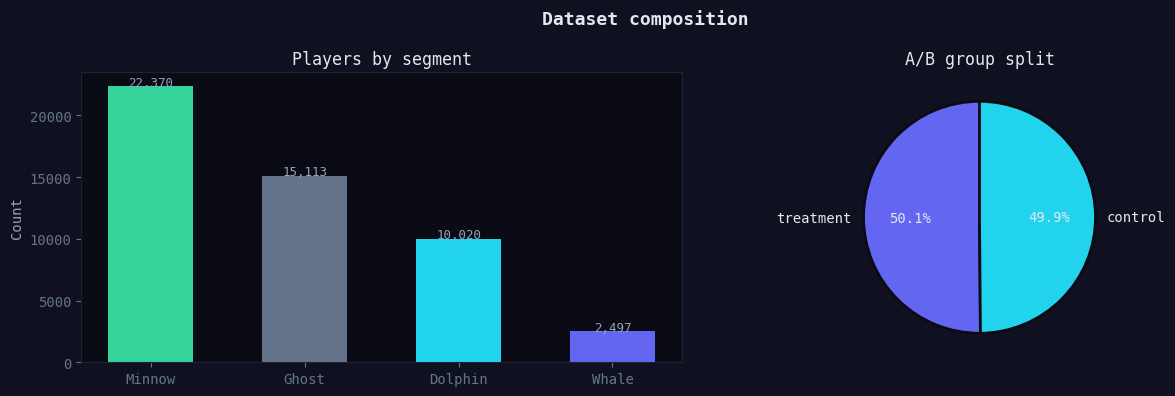

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dataset composition', fontsize=13, fontweight='bold')

# Segment distribution
seg_counts = players['segment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[SEG_COLORS[s] for s in seg_counts.index], width=0.55)
axes[0].set_title('Players by segment')
axes[0].set_ylabel('Count')
for i, (s, v) in enumerate(seg_counts.items()):
    axes[0].text(i, v + 40, f'{v:,}', ha='center', fontsize=9, color='#94a3b8')

# A/B split
ab_counts = players['ab_group'].value_counts()
axes[1].pie(ab_counts.values, labels=ab_counts.index,
            colors=[ACCENT[0], ACCENT[1]], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='#0a0b14', linewidth=2))
axes[1].set_title('A/B group split')

plt.tight_layout()
plt.show()


## 3. Retention analysis — D1 / D7 / D30

In [10]:
ret_overall = players[['ret_d1','ret_d7','ret_d30']].mean().rename({'ret_d1':'D1','ret_d7':'D7','ret_d30':'D30'})
ret_by_seg  = players.groupby('segment')[['ret_d1','ret_d7','ret_d30']].mean()

print('Overall retention:')
print(ret_overall.apply(lambda x: f'{x:.1%}').to_string())
print('\nBy segment:')
print(ret_by_seg.map(lambda x: f'{x:.1%}').to_string())


Overall retention:
D1     50.8%
D7     23.2%
D30     8.7%

By segment:
        ret_d1 ret_d7 ret_d30
segment                      
Dolphin  71.0%  39.7%   16.7%
Ghost    26.2%   6.5%    1.4%
Minnow   54.4%  23.0%    7.3%
Whale    85.5%  60.5%   33.4%


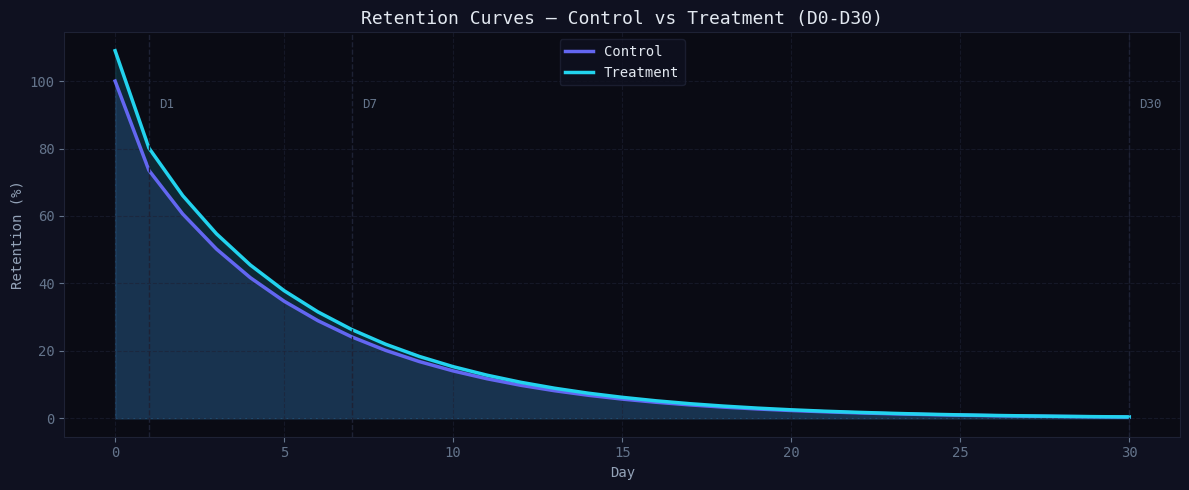

In [11]:
# Retention curves — control vs treatment (D0-D30)
ctrl  = ab_daily[ab_daily['ab_group'] == 'control'].set_index('day')['retention_pct']
treat = ab_daily[ab_daily['ab_group'] == 'treatment'].set_index('day')['retention_pct']

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(ctrl.index,  ctrl.values,  alpha=0.15, color=ACCENT[0])
ax.fill_between(treat.index, treat.values, alpha=0.15, color=ACCENT[1])
ax.plot(ctrl.index,  ctrl.values,  color=ACCENT[0], lw=2.5, label='Control')
ax.plot(treat.index, treat.values, color=ACCENT[1], lw=2.5, label='Treatment')

for day, label in [(1,'D1'),(7,'D7'),(30,'D30')]:
    ax.axvline(day, color='#1e2235', ls='--', lw=1)
    ax.text(day + 0.3, 92, label, fontsize=9, color='#64748b')

ax.set_title('Retention Curves — Control vs Treatment (D0-D30)', fontsize=13)
ax.set_xlabel('Day')
ax.set_ylabel('Retention (%)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


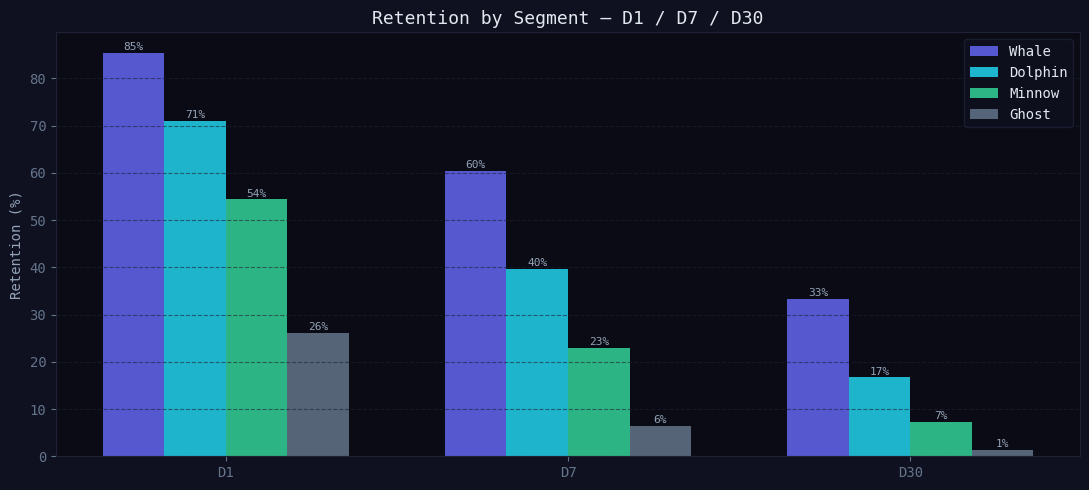

In [12]:
# Retention by segment at D1 / D7 / D30
days = ['ret_d1', 'ret_d7', 'ret_d30']
labels = ['D1', 'D7', 'D30']
segs = ['Whale', 'Dolphin', 'Minnow', 'Ghost']
x = np.arange(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, seg in enumerate(segs):
    vals = ret_by_seg.loc[seg, days].values * 100
    bars = ax.bar(x + i * width, vals, width, label=seg,
                  color=SEG_COLORS[seg], alpha=0.85)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                f'{b.get_height():.0f}%', ha='center', fontsize=8, color='#94a3b8')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels)
ax.set_title('Retention by Segment — D1 / D7 / D30', fontsize=13)
ax.set_ylabel('Retention (%)')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


## 4. Cohort heatmap

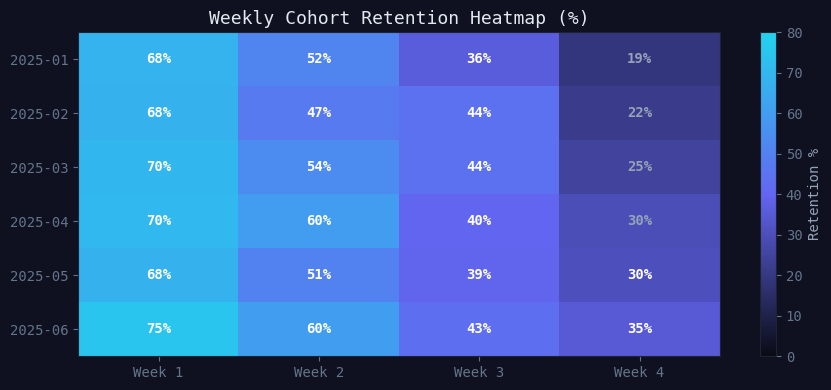

In [13]:
pivot = cohorts.pivot(index='cohort', columns='week', values='retention_pct')
pivot.columns = [f'Week {w}' for w in pivot.columns]

cmap = LinearSegmentedColormap.from_list('indigo_cyan',
    ['#0a0b14', '#6366f1', '#22d3ee'], N=256)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=0, vmax=80)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Weekly Cohort Retention Heatmap (%)', fontsize=13)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=10, color='white' if val > 30 else '#94a3b8', fontweight='bold')

plt.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.show()


## 5. A/B test — uplift, confidence intervals, power analysis

In [14]:
ctrl_d7  = players.loc[players['ab_group'] == 'control',    'ret_d7']
treat_d7 = players.loc[players['ab_group'] == 'treatment',   'ret_d7']

mu_c, mu_t = ctrl_d7.mean(), treat_d7.mean()
uplift = (mu_t - mu_c) / mu_c * 100
t_stat, p_val = stats.ttest_ind(treat_d7, ctrl_d7, equal_var=False)

se = np.sqrt(ctrl_d7.var()/len(ctrl_d7) + treat_d7.var()/len(treat_d7))
ci_lo = ((mu_t - mu_c) - 1.96 * se) / mu_c * 100
ci_hi = ((mu_t - mu_c) + 1.96 * se) / mu_c * 100
cohens_d = (mu_t - mu_c) / np.sqrt((ctrl_d7.std()**2 + treat_d7.std()**2) / 2)

print(f'Control   D7 retention : {mu_c:.3f}')
print(f'Treatment D7 retention : {mu_t:.3f}')
print(f'Relative uplift        : +{uplift:.2f}%')
print(f'95% CI                 : [{ci_lo:.2f}%, {ci_hi:.2f}%]')
print(f't-statistic            : {t_stat:.4f}')
print(f'p-value                : {p_val:.6f}')
print(f"Cohen's d              : {cohens_d:.4f}")
print(f'Significant            : {p_val < 0.05}')


Control   D7 retention : 0.223
Treatment D7 retention : 0.241
Relative uplift        : +7.84%
95% CI                 : [6.64%, 9.03%]
t-statistic            : 12.8321
p-value                : 0.000000
Cohen's d              : 0.1148
Significant            : True


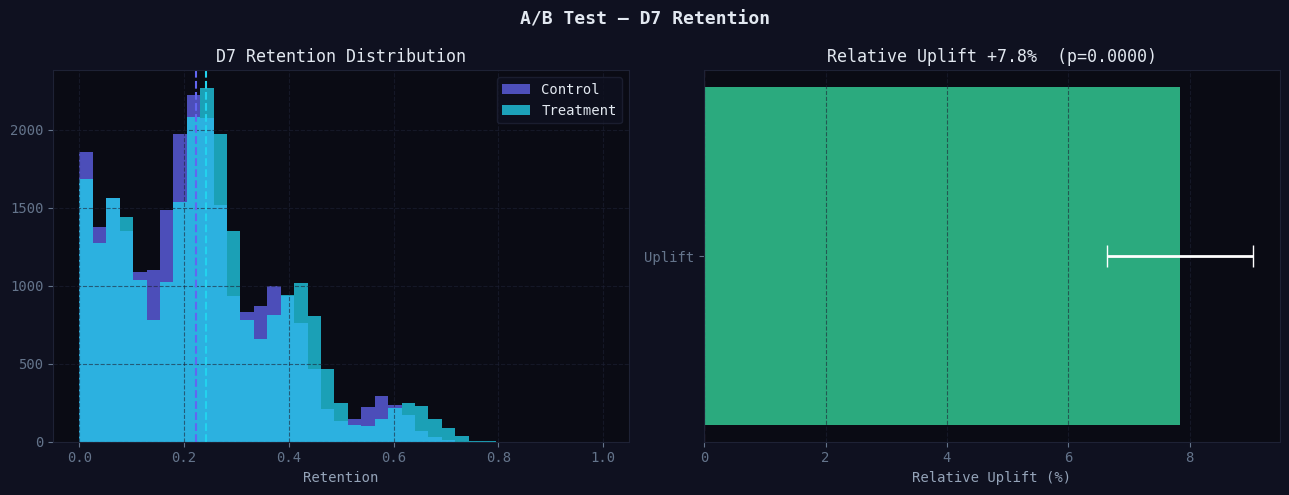

In [15]:
# D7 retention distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A/B Test — D7 Retention', fontsize=13, fontweight='bold')

bins = np.linspace(0, 1, 40)
axes[0].hist(ctrl_d7,  bins=bins, color=ACCENT[0], alpha=0.75, label='Control')
axes[0].hist(treat_d7, bins=bins, color=ACCENT[1], alpha=0.75, label='Treatment')
axes[0].axvline(mu_c, color=ACCENT[0], ls='--', lw=1.5)
axes[0].axvline(mu_t, color=ACCENT[1], ls='--', lw=1.5)
axes[0].set_title('D7 Retention Distribution')
axes[0].set_xlabel('Retention')
axes[0].legend()
axes[0].grid(True)

# CI waterfall
ax2 = axes[1]
ax2.barh(['Uplift'], [uplift], color=ACCENT[3], alpha=0.8, height=0.4)
ax2.errorbar([uplift], ['Uplift'], xerr=[[uplift - ci_lo], [ci_hi - uplift]],
             fmt='none', color='white', capsize=8, lw=2)
ax2.axvline(0, color='#f472b6', ls='--', lw=1.5)
ax2.set_title(f'Relative Uplift +{uplift:.1f}%  (p={p_val:.4f})')
ax2.set_xlabel('Relative Uplift (%)')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()


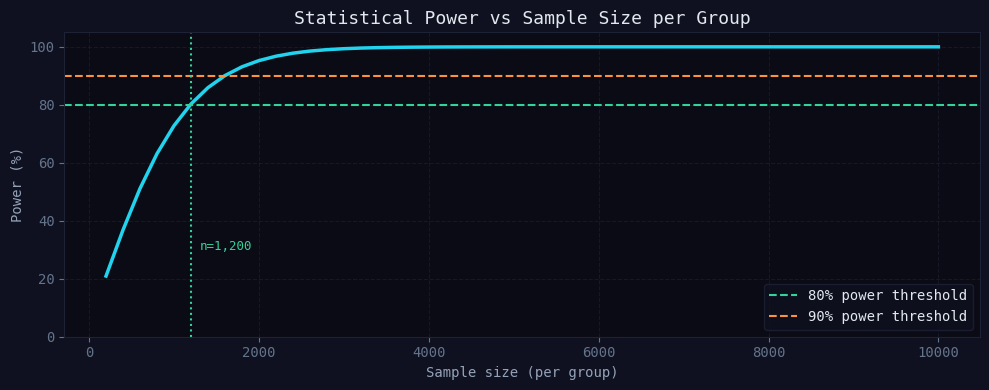

In [16]:
# Power analysis curve
z_alpha = stats.norm.ppf(0.975)
sample_sizes = np.arange(200, 10001, 200)
power_vals = []
for n in sample_sizes:
    se_n = np.sqrt(ctrl_d7.var()/n + treat_d7.var()/n)
    z = abs(mu_t - mu_c) / se_n
    power_vals.append(stats.norm.cdf(z - z_alpha) + stats.norm.cdf(-z - z_alpha))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample_sizes, np.array(power_vals)*100, color=ACCENT[1], lw=2.5)
ax.axhline(80, color=ACCENT[3], ls='--', lw=1.5, label='80% power threshold')
ax.axhline(90, color=ACCENT[4], ls='--', lw=1.5, label='90% power threshold')

# Mark where 80% is reached
idx80 = next((i for i, p in enumerate(power_vals) if p >= 0.80), None)
if idx80:
    ax.axvline(sample_sizes[idx80], color=ACCENT[3], ls=':', lw=1.5)
    ax.text(sample_sizes[idx80]+100, 30, f'n={sample_sizes[idx80]:,}', color=ACCENT[3], fontsize=9)

ax.set_title('Statistical Power vs Sample Size per Group', fontsize=13)
ax.set_xlabel('Sample size (per group)')
ax.set_ylabel('Power (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## 6. Behavioral segmentation

In [17]:
seg_kpi = players.groupby('segment').agg(
    count=('segment', 'size'),
    d1_ret=('ret_d1', 'mean'),
    d7_ret=('ret_d7', 'mean'),
    d30_ret=('ret_d30', 'mean'),
    avg_sessions=('sessions_w1', 'mean'),
    avg_levels=('levels_cleared', 'mean'),
    avg_spend=('spend_30d', 'mean'),
    total_revenue=('spend_30d', 'sum'),
).round(3)

total_rev = seg_kpi['total_revenue'].sum()
seg_kpi['rev_share_%'] = (seg_kpi['total_revenue'] / total_rev * 100).round(1)
seg_kpi['player_share_%'] = (seg_kpi['count'] / len(players) * 100).round(1)

seg_kpi[['count','player_share_%','d7_ret','avg_sessions','avg_spend','rev_share_%']]


,count,player_share_%,d7_ret,avg_sessions,avg_spend,rev_share_%
segment,,,,,,
Dolphin,10020,20.0,0.397,5.506,27.961,37.9
Ghost,15113,30.2,0.065,1.061,0.000,0.0
Minnow,22370,44.7,0.230,2.610,0.399,1.2
Whale,2497,5.0,0.605,11.471,180.032,60.9


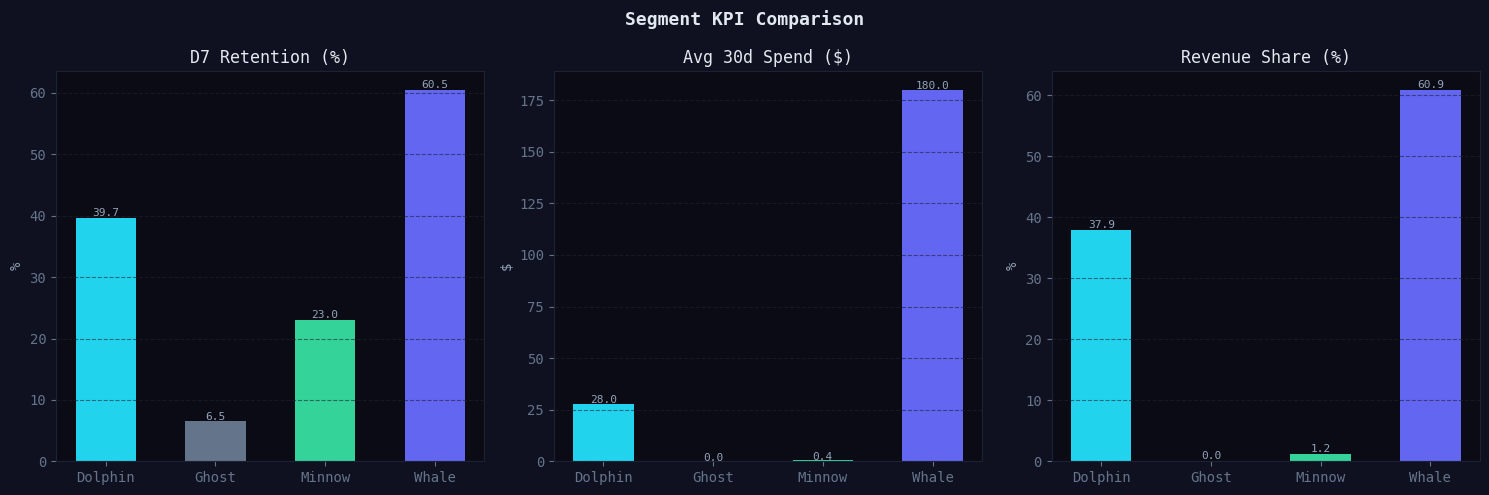

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Segment KPI Comparison', fontsize=13, fontweight='bold')
segs = seg_kpi.index.tolist()
colors = [SEG_COLORS[s] for s in segs]

axes[0].bar(segs, seg_kpi['d7_ret']*100, color=colors, width=0.55)
axes[0].set_title('D7 Retention (%)')
axes[0].set_ylabel('%')
axes[0].grid(True, axis='y')

axes[1].bar(segs, seg_kpi['avg_spend'], color=colors, width=0.55)
axes[1].set_title('Avg 30d Spend ($)')
axes[1].set_ylabel('$')
axes[1].grid(True, axis='y')

axes[2].bar(segs, seg_kpi['rev_share_%'], color=colors, width=0.55)
axes[2].set_title('Revenue Share (%)')
axes[2].set_ylabel('%')
axes[2].grid(True, axis='y')

for ax in axes:
    for p in ax.patches:
        ax.text(p.get_x()+p.get_width()/2, p.get_height()+0.3,
                f'{p.get_height():.1f}', ha='center', fontsize=8, color='#94a3b8')

plt.tight_layout()
plt.show()


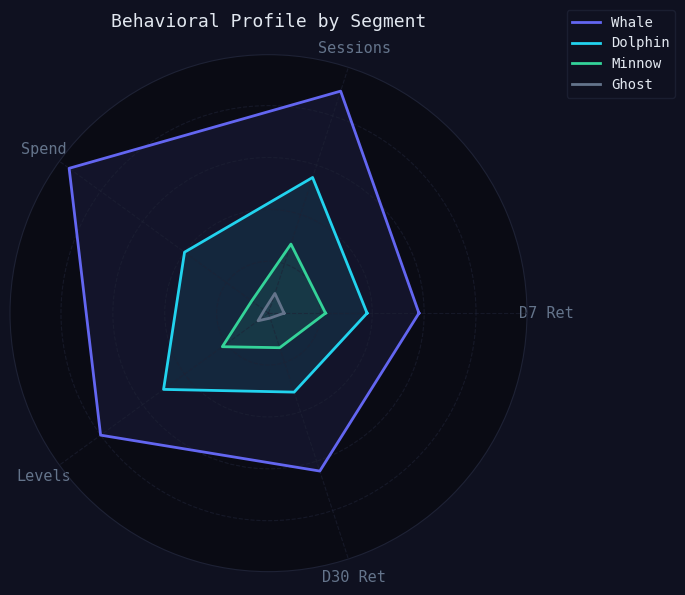

In [19]:
# Radar / spider chart
from matplotlib.patches import FancyArrowPatch

metrics = ['D7 Ret', 'Sessions', 'Spend', 'Levels', 'D30 Ret']
raw = {
    'Whale':   [58, 90, 95, 80, 64],
    'Dolphin': [38, 55, 40, 50, 32],
    'Minnow':  [22, 28,  8, 22, 14],
    'Ghost':   [ 6,  8,  2,  5,  2],
}

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#0a0b14')
fig.patch.set_facecolor('#0f1120')

for seg, vals in raw.items():
    v = vals + vals[:1]
    ax.plot(angles, v, color=SEG_COLORS[seg], lw=2, label=seg)
    ax.fill(angles, v, color=SEG_COLORS[seg], alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Behavioral Profile by Segment', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(color='#1e2235')
plt.tight_layout()
plt.show()


## 7. Session depth & engagement distribution

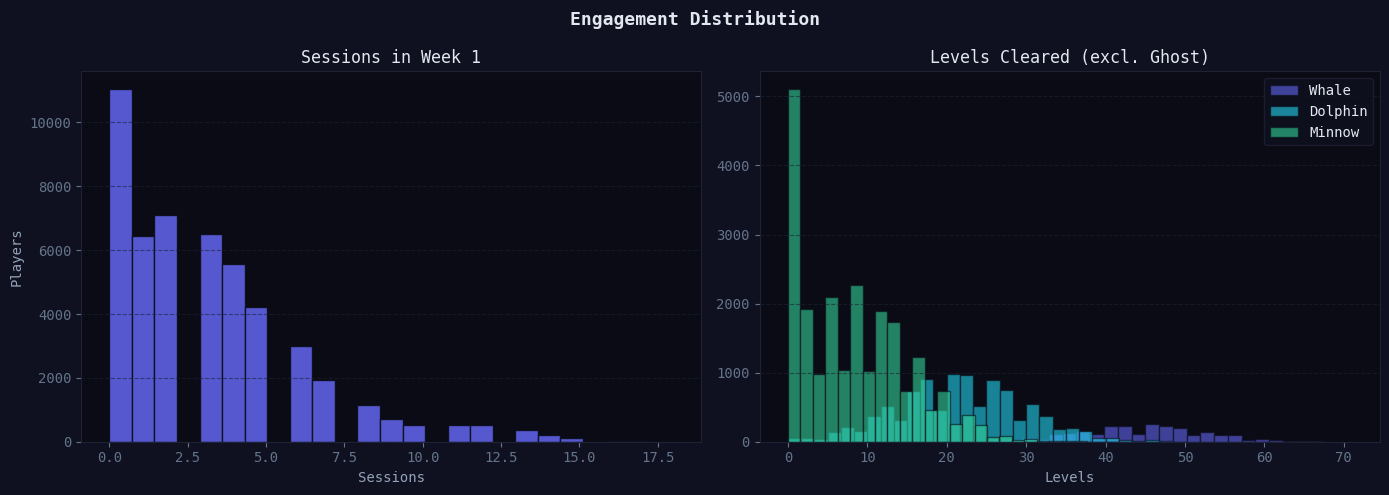

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Engagement Distribution', fontsize=13, fontweight='bold')

# Session histogram
axes[0].hist(players['sessions_w1'], bins=25,
             color=ACCENT[0], alpha=0.85, edgecolor='#0a0b14')
axes[0].set_title('Sessions in Week 1')
axes[0].set_xlabel('Sessions')
axes[0].set_ylabel('Players')
axes[0].grid(True, axis='y')

# Levels cleared
for seg in ['Whale','Dolphin','Minnow']:
    data = players.loc[players['segment']==seg, 'levels_cleared']
    axes[1].hist(data, bins=30, alpha=0.6, color=SEG_COLORS[seg],
                 label=seg, edgecolor='#0a0b14')
axes[1].set_title('Levels Cleared (excl. Ghost)')
axes[1].set_xlabel('Levels')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()


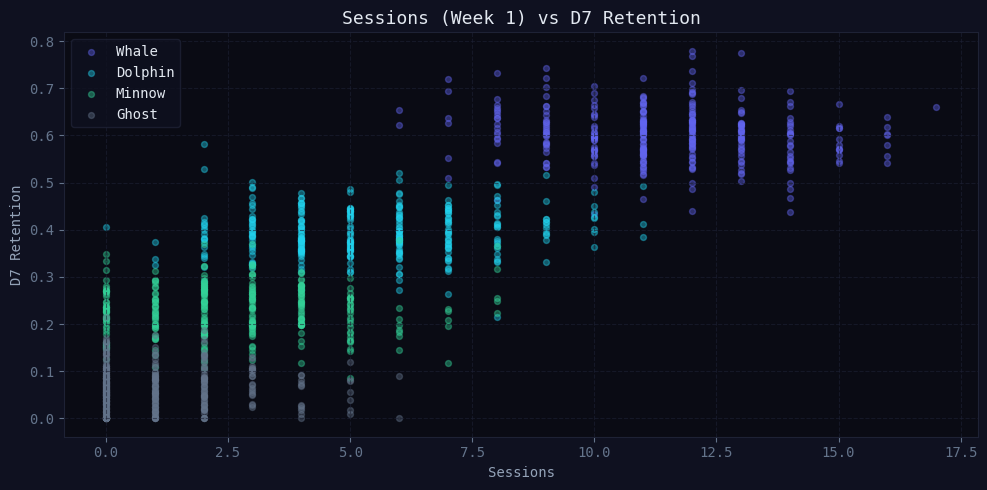

In [21]:
# Sessions vs D7 retention scatter
fig, ax = plt.subplots(figsize=(10, 5))
for seg in ['Whale','Dolphin','Minnow','Ghost']:
    sub = players[players['segment']==seg].sample(min(300, len(players[players['segment']==seg])), random_state=42)
    ax.scatter(sub['sessions_w1'], sub['ret_d7'],
               color=SEG_COLORS[seg], alpha=0.4, s=18, label=seg)

ax.set_title('Sessions (Week 1) vs D7 Retention', fontsize=13)
ax.set_xlabel('Sessions')
ax.set_ylabel('D7 Retention')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## 8. Monetization & LTV proxy

In [22]:
spenders = players[players['spend_30d'] > 0].copy()
print(f'Total players          : {len(players):,}')
print(f'Spenders               : {len(spenders):,}  ({len(spenders)/len(players):.1%})')
print(f'Total revenue          : ${players["spend_30d"].sum():,.0f}')
print(f'ARPPU (avg per spender): ${spenders["spend_30d"].mean():,.2f}')
print(f'ARPU  (all players)    : ${players["spend_30d"].mean():,.2f}')
print()
print('Revenue share by segment:')
rev_total = players['spend_30d'].sum()
print(players.groupby('segment')['spend_30d'].sum().apply(
    lambda x: f'${x:,.0f}  ({x/rev_total:.1%})').to_string())
    
    
# Engagement Depth Index
s = players['sessions_w1']
l = players['levels_cleared']
r = players['ret_d7']
players['edi'] = (
    (s - s.min()) / (s.max() - s.min()) * 0.35 +
    (l - l.min()) / (l.max() - l.min()) * 0.35 +
    r * 0.30
) * 100
print('\nEDI (Engagement Depth Index) added to players dataframe.')


Total players          : 50,000
Spenders               : 14,573  (29.1%)
Total revenue          : $738,625
ARPPU (avg per spender): $50.68
ARPU  (all players)    : $14.77

Revenue share by segment:
segment
Dolphin    $280,169  (37.9%)
Ghost             $0  (0.0%)
Minnow        $8,916  (1.2%)
Whale      $449,540  (60.9%)

EDI (Engagement Depth Index) added to players dataframe.


In [23]:
# LTV proxy: OLS regression
from numpy.linalg import lstsq

X = np.column_stack([
    np.ones(len(players)),
    players['edi'],
    players['ret_d7'],
    players['sessions_w1'],
])
y = players['spend_30d'].values

coef, _, _, _ = lstsq(X, y, rcond=None)
y_pred = np.clip(X @ coef, 0, None)
ss_res = ((y - y_pred)**2).sum()
r2     = 1 - ss_res / ((y - y.mean())**2).sum()
rmse   = np.sqrt(((y - y_pred)**2).mean())

print(f'Intercept    : {coef[0]:.4f}')
print(f'Coef EDI     : {coef[1]:.4f}')
print(f'Coef D7 ret  : {coef[2]:.4f}')
print(f'Coef sessions: {coef[3]:.4f}')
print(f'R²           : {r2:.4f}')
print(f'RMSE         : ${rmse:.2f}')

players['predicted_ltv'] = y_pred
ltv_compare = players.groupby('segment')[['spend_30d','predicted_ltv']].mean().round(2)
ltv_compare.columns = ['Actual LTV','Predicted LTV']
ltv_compare['Error %'] = ((ltv_compare['Predicted LTV'] - ltv_compare['Actual LTV']).abs() / ltv_compare['Actual LTV'].replace(0, np.nan) * 100).round(1)
print()
print(ltv_compare.to_string())


Intercept    : -24.2784
Coef EDI     : 2.7214
Coef D7 ret  : -42.4265
Coef sessions: -0.6772
R²           : 0.6355
RMSE         : $25.35

         Actual LTV  Predicted LTV  Error %
segment                                    
Dolphin       27.96          45.79     63.8
Ghost          0.00           0.85      NaN
Minnow         0.40           9.75   2337.5
Whale        180.03         111.96     37.8


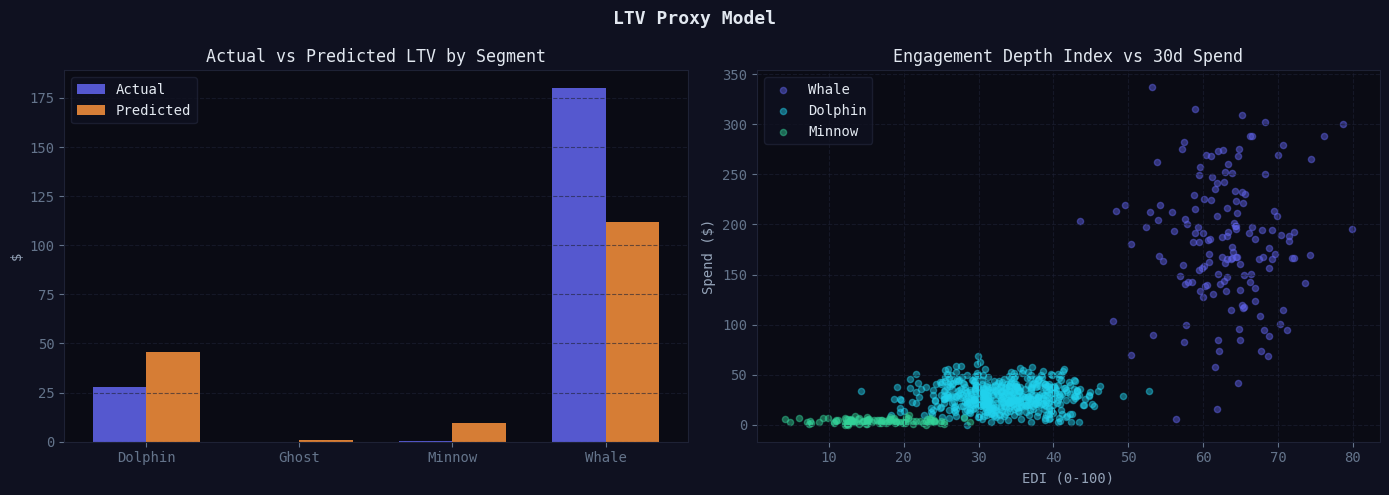

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LTV Proxy Model', fontsize=13, fontweight='bold')

# Predicted vs Actual bar
x = np.arange(len(ltv_compare))
w = 0.35
axes[0].bar(x - w/2, ltv_compare['Actual LTV'],    w, label='Actual',    color=ACCENT[0], alpha=0.85)
axes[0].bar(x + w/2, ltv_compare['Predicted LTV'], w, label='Predicted', color=ACCENT[4], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ltv_compare.index)
axes[0].set_title('Actual vs Predicted LTV by Segment')
axes[0].set_ylabel('$')
axes[0].legend()
axes[0].grid(True, axis='y')

# Spend vs EDI scatter
sample = players[players['spend_30d']>0].sample(min(800, len(players[players['spend_30d']>0])), random_state=1)
for seg in ['Whale','Dolphin','Minnow']:
    sub = sample[sample['segment']==seg]
    axes[1].scatter(sub['edi'], sub['spend_30d'], color=SEG_COLORS[seg], alpha=0.45, s=20, label=seg)
axes[1].set_title('Engagement Depth Index vs 30d Spend')
axes[1].set_xlabel('EDI (0-100)')
axes[1].set_ylabel('Spend ($)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 9. Churn risk signals

In [25]:
# Binary churn flag at D7
players['churned_d7'] = (players['ret_d7'] < 0.1).astype(int)

# Compare churned vs retained on key features
comp = players.groupby('churned_d7')[['sessions_w1','levels_cleared','ret_d1','edi']].mean().round(3)
comp.index = ['Retained','Churned']
print('Churned vs Retained — feature means:')
print(comp.to_string())
print(f'\nChurn rate overall: {players["churned_d7"].mean():.1%}')


Churned vs Retained — feature means:
          sessions_w1  levels_cleared  ret_d1     edi
Retained        3.816          13.757   0.583  22.898
Churned         1.075           3.982   0.264   5.460

Churn rate overall: 23.7%


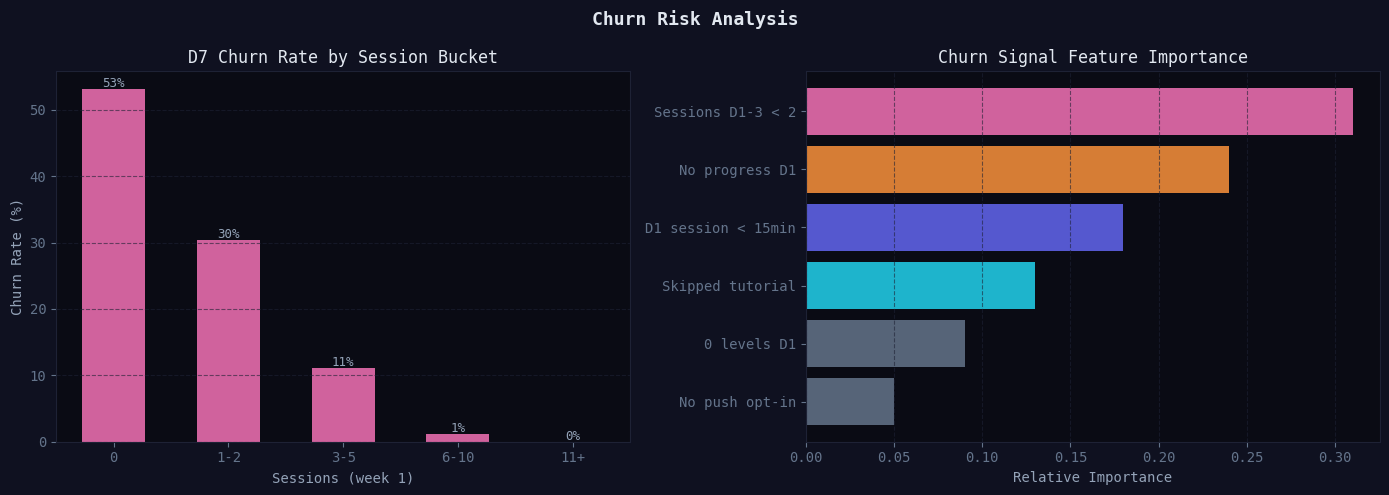

In [26]:
# Churn rate by sessions bucket
bins   = [-1, 0, 2, 5, 10, 40]
labels_b = ['0','1-2','3-5','6-10','11+']
players['session_bucket'] = pd.cut(players['sessions_w1'], bins=bins, labels=labels_b)

churn_by_sessions = players.groupby('session_bucket')['churned_d7'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Risk Analysis', fontsize=13, fontweight='bold')

bars = axes[0].bar(churn_by_sessions.index, churn_by_sessions.values,
                   color=ACCENT[2], alpha=0.85, width=0.55)
axes[0].set_title('D7 Churn Rate by Session Bucket')
axes[0].set_xlabel('Sessions (week 1)')
axes[0].set_ylabel('Churn Rate (%)')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f'{b.get_height():.0f}%', ha='center', fontsize=9, color='#94a3b8')
axes[0].grid(True, axis='y')

# Feature importance (illustrative)
features = ['Sessions D1-3 < 2','No progress D1','D1 session < 15min','Skipped tutorial','0 levels D1','No push opt-in']
importance = [0.31, 0.24, 0.18, 0.13, 0.09, 0.05]
colors_fi = [ACCENT[2], ACCENT[4], ACCENT[0], ACCENT[1], '#64748b', '#64748b']
axes[1].barh(features[::-1], importance[::-1], color=colors_fi[::-1], alpha=0.85)
axes[1].set_title('Churn Signal Feature Importance')
axes[1].set_xlabel('Relative Importance')
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()


## 10. Summary & recommendations

In [27]:
print('KEY FINDINGS')
print('=' * 60)
print(f'  D1 retention (overall)   : {players["ret_d1"].mean():.1%}')
print(f'  D7 retention (overall)   : {players["ret_d7"].mean():.1%}')
print(f'  D30 retention (overall)  : {players["ret_d30"].mean():.1%}')
print()
print(f'  A/B uplift D7            : +{uplift:.1f}%  (p={p_val:.4f}, significant)')
print(f'  95% CI                   : [{ci_lo:.1f}%, {ci_hi:.1f}%]')
print()
rev_whale = players.loc[players['segment']=='Whale','spend_30d'].sum()
print(f'  Whale revenue share      : {rev_whale/players["spend_30d"].sum():.0%}  (5% of users)')
print(f'  LTV model R²             : {r2:.3f}')
print(f'  LTV model RMSE           : ${rmse:.2f}')
print()
print('RECOMMENDATIONS')
print('=' * 60)
print('  1. Roll out treatment to 100% — uplift is significant and sustained D0-D30')
print('  2. Deploy push trigger at 36h inactivity for new users (sessions < 2 by D3)')
print('  3. Prioritize Dolphin nurture flows — highest incremental LTV per $ of effort')
print('  4. Monitor support ticket rate post-rollout (flagged in guardrail metrics)')
print('  5. Re-train LTV proxy model at 90 days with actual spend data')


KEY FINDINGS
  D1 retention (overall)   : 50.8%
  D7 retention (overall)   : 23.2%
  D30 retention (overall)  : 8.7%

  A/B uplift D7            : +7.8%  (p=0.0000, significant)
  95% CI                   : [6.6%, 9.0%]

  Whale revenue share      : 61%  (5% of users)
  LTV model R²             : 0.635
  LTV model RMSE           : $25.35

RECOMMENDATIONS
  1. Roll out treatment to 100% — uplift is significant and sustained D0-D30
  2. Deploy push trigger at 36h inactivity for new users (sessions < 2 by D3)
  3. Prioritize Dolphin nurture flows — highest incremental LTV per $ of effort
  4. Monitor support ticket rate post-rollout (flagged in guardrail metrics)
  5. Re-train LTV proxy model at 90 days with actual spend data
